# Credit Risk & Customer Financial Behaviour Analysis

### SQL & Python Data Analytics Project

**Tools Used:** SQL, Python, Pandas, NumPy, Matplotlib

---

## 1. Project Overview

This project analyzes customer financial profiles and transaction behaviour to identify patterns associated with different levels of financial risk.

Using SQL and Python, the analysis examines credit scores, debt-to-income (DTI) ratios, yearly income, total debt, spending behaviour, and transaction patterns across 4,941 customers.

The project develops a rule-based customer risk segmentation framework and an exploratory composite risk-scoring framework to identify and prioritize customers with relatively elevated financial risk profiles.

## 2. Business Objectives

The analysis aims to:

- Understand the distribution of customer credit scores and financial characteristics.
- Examine the relationship between credit quality, debt burden, and transaction behaviour.
- Analyze customer spending and transaction patterns.
- Segment customers into different financial-risk categories.
- Identify customers with unusually high debt burdens or transaction behaviour.
- Develop an interpretable composite risk-scoring framework for customer prioritization.
- Compare rule-based risk segmentation with a continuous risk-scoring approach.

## 3. Dataset Overview

The analysis is based on transaction-level customer data containing financial and behavioural information.

### Key variables include:

- `client_id` — Unique customer identifier
- `transaction_id` — Unique transaction identifier
- `credit_score` — Customer credit score
- `yearly_income` — Annual customer income
- `total_debt` — Customer debt exposure
- `amount` — Transaction amount
- `date` — Transaction date
- `use_chip` — Transaction channel

The transaction-level data is transformed into a customer-level analytical dataset to calculate additional features such as total spending, transaction frequency, debt-to-income ratio, and transaction variability.

> **Disclaimer:** The risk segments and composite risk scores developed in this project are exploratory analytical frameworks created for portfolio and learning purposes. They are not validated credit-risk models and should not be interpreted as predictions of default, fraud, or actual lending decisions.

# 4. Data Preparation & Quality Checks

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/Customer_financial_profiles.csv")

In [ ]:
df.head()

,id,current_age,birth_year,birth_month,gender,address,per_capita_income,yearly_income,total_debt,credit_score,...,transaction_id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip
0,1,64,1961,3,Female,"Street 286, Indore, Madhya Pradesh - 452645",86125,1033501,280435,715,...,1251,28-03-2024,CLTIND00104,CRD001042,1483.94,Yes,MCH00496,Mumbai,Maharashtra,452645
1,2,39,1986,12,Female,"Street 268, Kolkata, West Bengal - 700555",68414,820965,0,834,...,9976,20-09-2025,CLTIND00213,CRD002132,1274.72,Yes,MCH00374,Mumbai,Maharashtra,700555
2,3,50,1975,7,Female,"Street 262, Lucknow, Uttar Pradesh - 226797",22595,271138,0,609,...,6084,02-10-2024,CLTIND03292,CRD032922,7622.04,No,MCH00108,Kolkata,West Bengal,226797
3,4,27,1998,2,Male,"Street 265, Nagpur, Maharashtra - 440623",24158,289898,0,782,...,3350,02-09-2023,CLTIND05205,CRD052053,3970.48,Yes,MCH00001,Indore,Madhya Pradesh,440623
4,5,45,1980,7,Other,"Street 157, Delhi, Delhi - 110965",45475,545697,117821,608,...,11725,25-05-2025,CLTIND04910,CRD049101,418.45,No,MCH00254,Bengaluru,Karnataka,110965


In [ ]:
df.shape

(20000, 21)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 20000 non-null  int64  
 1   current_age        20000 non-null  int64  
 2   birth_year         20000 non-null  int64  
 3   birth_month        20000 non-null  int64  
 4   gender             20000 non-null  object 
 5   address            20000 non-null  object 
 6   per_capita_income  20000 non-null  int64  
 7   yearly_income      20000 non-null  int64  
 8   total_debt         20000 non-null  int64  
 9   credit_score       20000 non-null  int64  
 10  num_credit_cards   20000 non-null  int64  
 11  transaction_id     20000 non-null  int64  
 12  date               20000 non-null  object 
 13  client_id          20000 non-null  object 
 14  card_id            20000 non-null  object 
 15  amount             20000 non-null  float64
 16  use_chip           200

In [ ]:
df.describe()

,id,current_age,birth_year,birth_month,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards,transaction_id,amount,zip
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,2.000000e+04,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,44.210100,1980.789900,6.479150,61234.419700,7.348131e+05,1.345380e+05,702.979750,2.873750,10015.488700,3082.286901,445976.994400
std,5773.647028,14.992515,14.992515,3.459532,35354.273099,4.242512e+05,1.739757e+05,76.993944,1.162574,5802.389323,2117.081361,168230.579911
min,1.000000,19.000000,1955.000000,1.000000,12500.000000,1.500000e+05,0.000000e+00,421.000000,1.000000,1.000000,105.160000,110102.000000
25%,5000.750000,31.000000,1968.000000,3.000000,35671.000000,4.280470e+05,0.000000e+00,648.000000,2.000000,4971.000000,1531.182500,380703.500000
50%,10000.500000,44.000000,1981.000000,7.000000,54896.000000,6.587560e+05,8.250300e+04,699.000000,3.000000,10026.500000,2601.650000,440388.000000
75%,15000.250000,57.000000,1994.000000,10.000000,74842.000000,8.981090e+05,2.008720e+05,757.000000,4.000000,15062.750000,4116.155000,560252.000000
max,20000.000000,70.000000,2006.000000,12.000000,250000.000000,3.000000e+06,1.817384e+06,900.000000,5.000000,20000.000000,19806.630000,800988.000000


## Data Quality Checks

### Missing Values



In [ ]:
df.isnull().sum()

,0
id,0
current_age,0
birth_year,0
birth_month,0
gender,0
address,0
per_capita_income,0
yearly_income,0
total_debt,0
credit_score,0


### Duplicate Rows


In [ ]:
df.duplicated().sum()

np.int64(0)

### Unique Customers and Transactions

In [ ]:
df['client_id'].nunique()

4941

In [ ]:
df['transaction_id'].nunique()

13028

##Convert the date column

1 — Convert date

In [ ]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

2 — Check the result

In [ ]:
df['date'].dtype

dtype('<M8[ns]')

3 — Check the date range

In [ ]:
df['date'].min(), df['date'].max()

(Timestamp('2023-01-01 00:00:00'), Timestamp('2025-10-31 00:00:00'))

##4 — Creating useful date features

In [ ]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.month_name()
df['day_of_week'] = df['date'].dt.day_name()

In [ ]:
df[['date', 'year', 'month', 'month_name', 'day_of_week']].head()

,date,year,month,month_name,day_of_week
0,2024-03-28,2024,3,March,Thursday
1,2025-09-20,2025,9,September,Saturday
2,2024-10-02,2024,10,October,Wednesday
3,2023-09-02,2023,9,September,Saturday
4,2025-05-25,2025,5,May,Sunday


##5 — Customer-level feature engineering

1 — Create the financial/customer base

In [ ]:
customer_base = df.groupby('client_id').agg({
    'credit_score': 'first',
    'yearly_income': 'first',
    'total_debt': 'first'
}).reset_index()

 2 — Create DTI

In [ ]:
customer_base['dti'] = (
    customer_base['total_debt'] /
    customer_base['yearly_income']
)

3— Create credit groups

In [ ]:
customer_base['credit_group'] = pd.cut(
    customer_base['credit_score'],
    bins=[-float('inf'), 649, 749, float('inf')],
    labels=['Low', 'Medium', 'High']
)

4 — Create transaction statistics

In [ ]:
transaction_stats = df.groupby('client_id').agg(
    total_transactions=('transaction_id', 'count'),
    total_spending=('amount', 'sum'),
    avg_transaction_amount=('amount', 'mean'),
    transaction_stddev=('amount', 'std')
).reset_index()

5 — Combine them

In [ ]:
customer_data = customer_base.merge(
    transaction_stats,
    on='client_id',
    how='left'
)

In [ ]:
customer_data.shape

(4941, 10)

##6 — Validating Python against SQL

1 — Credit groups

In [ ]:
customer_data['credit_group'].value_counts()

,count
credit_group,
Medium,2288
High,1375
Low,1278


2 — Average DTI by credit group

In [ ]:
customer_data.groupby('credit_group', observed=False)['dti'].mean()

/tmp/ipykernel_1413/947075550.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  customer_data.groupby('credit_group')['dti'].mean()


,dti
credit_group,
Low,0.244441
Medium,0.180252
High,0.128321


3 — Average debt by credit group

In [ ]:
customer_data.groupby('credit_group', observed=False)['total_debt'].mean()

/tmp/ipykernel_1413/3548864484.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  customer_data.groupby('credit_group')['total_debt'].mean()


,total_debt
credit_group,
Low,166501.979656
Medium,115811.415647
High,83657.998545


# 7. Exploratory Data Analysis

##Credit Score Distribution
How are customers distributed across credit scores?

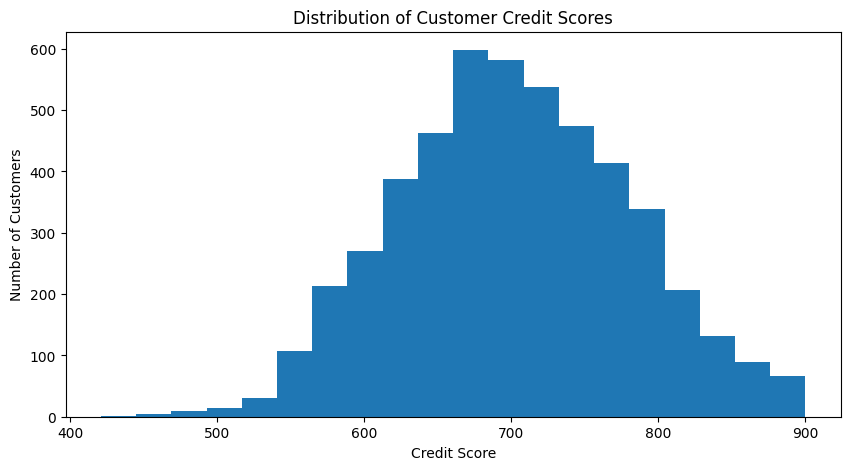

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(customer_data['credit_score'], bins=20)

plt.title('Distribution of Customer Credit Scores')
plt.xlabel('Credit Score')
plt.ylabel('Number of Customers')

plt.show()

##8 — Credit Score vs DTI

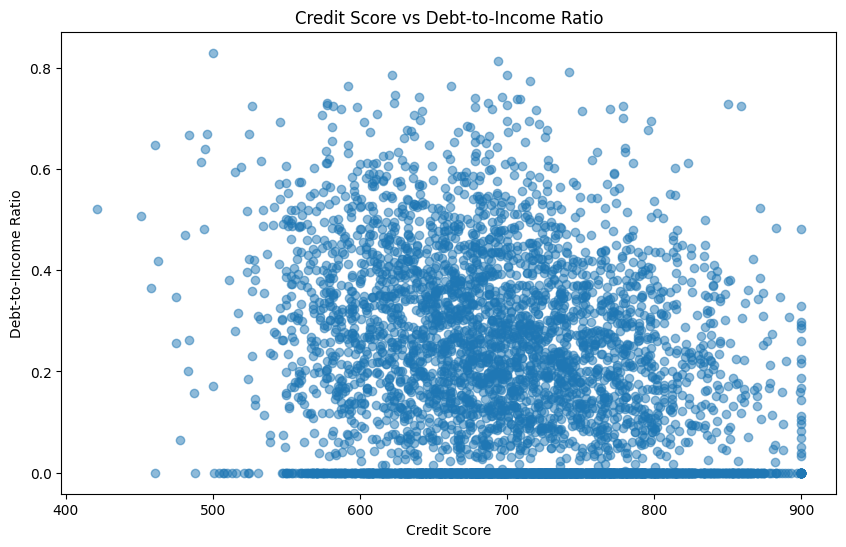

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    customer_data['credit_score'],
    customer_data['dti'],
    alpha=0.5
)

plt.title('Credit Score vs Debt-to-Income Ratio')
plt.xlabel('Credit Score')
plt.ylabel('Debt-to-Income Ratio')

plt.show()

##9 — Quantifying the relationship

In [ ]:
customer_data[['credit_score', 'dti']].corr()

,credit_score,dti
credit_score,1.000000,-0.251513
dti,-0.251513,1.000000


**Key Insight:** Credit score and DTI exhibit a negative correlation of approximately **-0.25**, indicating that a higher debt burden tends to be associated with lower credit scores. However, the relationship is moderate and does not explain credit score variation on its own.

# 10. Customer Risk Segmentation

## Risk Segment Distribution

How are customers distributed across High, Elevated, and Standard Risk segments?

### Risk Segment Methodology

Customers are initially classified as **Standard Risk**.

- **High Risk:** Credit score below 650 **and** DTI greater than or equal to 50%.
- **Elevated Risk:** Credit score below 650 **or** DTI greater than or equal to 50%, excluding customers already classified as High Risk.
- **Standard Risk:** Customers who do not meet either of the above conditions.

These thresholds are project-defined analytical rules and are not based on an official credit-risk policy.

In [ ]:
customer_data['risk_segment'] = 'Standard Risk'

customer_data.loc[
    (customer_data['credit_score'] < 650) &
    (customer_data['dti'] >= 0.50),
    'risk_segment'
] = 'High Risk'

customer_data.loc[
    (
        (customer_data['credit_score'] < 650) |
        (customer_data['dti'] >= 0.50)
    ) &
    (customer_data['risk_segment'] != 'High Risk'),
    'risk_segment'
] = 'Elevated Risk'

In [ ]:
customer_data['risk_segment'].value_counts()

,count
risk_segment,
Standard Risk,3497
Elevated Risk,1298
High Risk,146


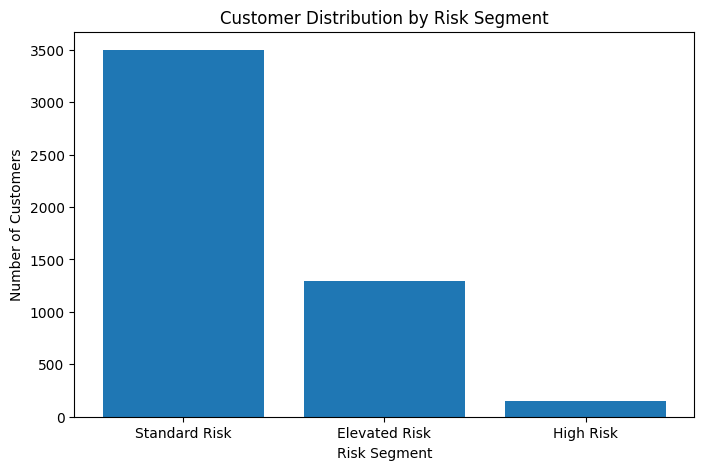

In [ ]:
risk_counts = customer_data['risk_segment'].value_counts()

plt.figure(figsize=(8, 5))

plt.bar(risk_counts.index, risk_counts.values)

plt.title('Customer Distribution by Risk Segment')
plt.xlabel('Risk Segment')
plt.ylabel('Number of Customers')

plt.show()

##11 — Comparing financial risk across segments
We want to visually compare average DTI across our three risk segments.

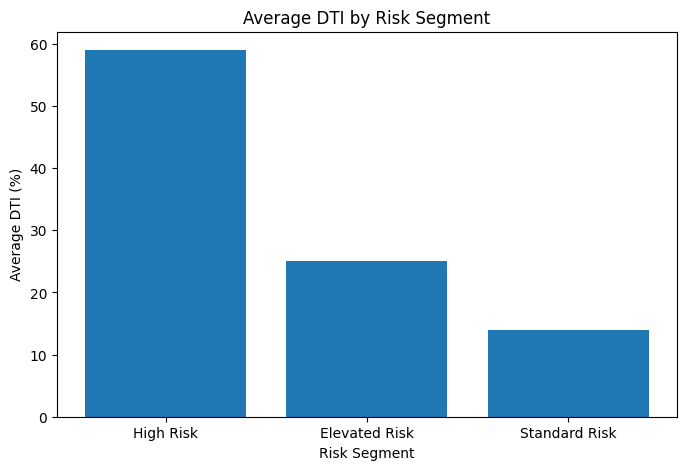

In [ ]:
risk_dti = customer_data.groupby('risk_segment')['dti'].mean() * 100

risk_dti = risk_dti.reindex([
    'High Risk',
    'Elevated Risk',
    'Standard Risk'
])

plt.figure(figsize=(8, 5))

plt.bar(risk_dti.index, risk_dti.values)

plt.title('Average DTI by Risk Segment')
plt.xlabel('Risk Segment')
plt.ylabel('Average DTI (%)')

plt.show()

##12 — Spending behaviour across risk segments
Do customers in different risk segments exhibit different transaction-spending behaviour?

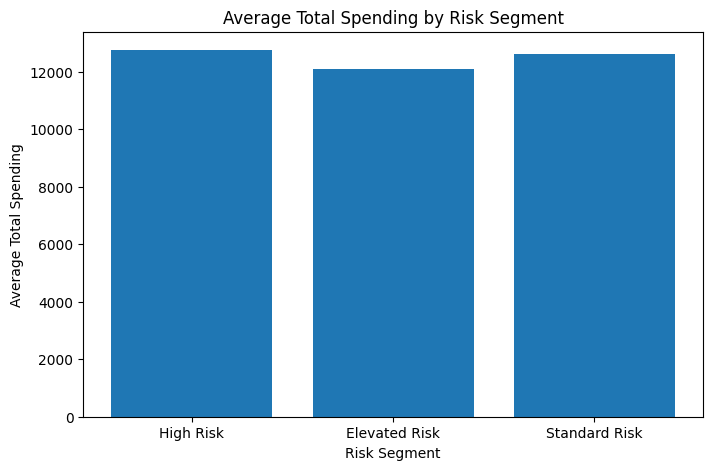

In [ ]:
risk_spending = (
    customer_data
    .groupby('risk_segment')['total_spending']
    .mean()
    .reindex([
        'High Risk',
        'Elevated Risk',
        'Standard Risk'
    ])
)

plt.figure(figsize=(8, 5))

plt.bar(risk_spending.index, risk_spending.values)

plt.title('Average Total Spending by Risk Segment')
plt.xlabel('Risk Segment')
plt.ylabel('Average Total Spending')

plt.show()

##13 — Does transaction frequency differ across risk segments?

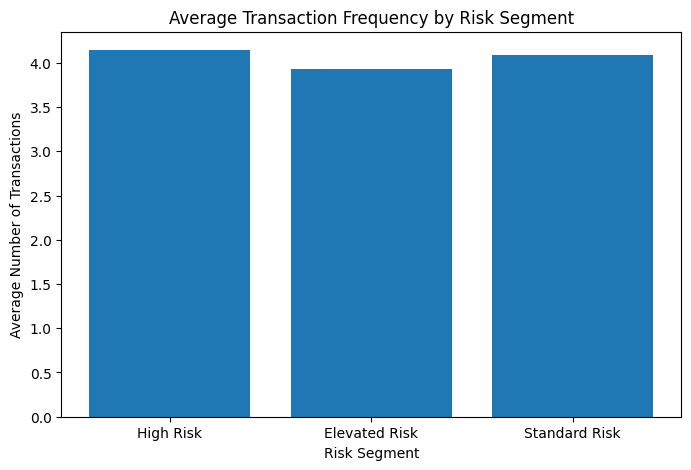

In [ ]:
risk_transactions = (
    customer_data
    .groupby('risk_segment')['total_transactions']
    .mean()
    .reindex([
        'High Risk',
        'Elevated Risk',
        'Standard Risk'
    ])
)

plt.figure(figsize=(8, 5))

plt.bar(risk_transactions.index, risk_transactions.values)

plt.title('Average Transaction Frequency by Risk Segment')
plt.xlabel('Risk Segment')
plt.ylabel('Average Number of Transactions')

plt.show()

##14 Do High-Risk customers show greater variability in their transaction amounts?

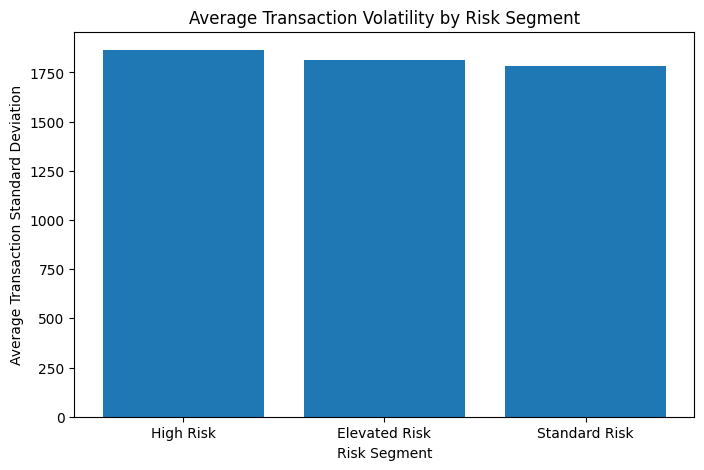

In [ ]:
risk_volatility = (
    customer_data
    .groupby('risk_segment')['transaction_stddev']
    .mean()
    .reindex([
        'High Risk',
        'Elevated Risk',
        'Standard Risk'
    ])
)

plt.figure(figsize=(8, 5))

plt.bar(risk_volatility.index, risk_volatility.values)

plt.title('Average Transaction Volatility by Risk Segment')
plt.xlabel('Risk Segment')
plt.ylabel('Average Transaction Standard Deviation')

plt.show()

##15 — looking for actual anomalies
Which individual customers behave unusually relative to the rest of the population?

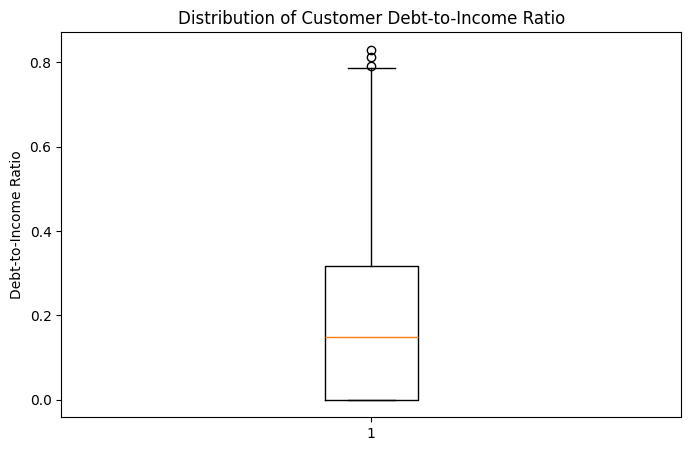

In [ ]:
plt.figure(figsize=(8, 5))

plt.boxplot(customer_data['dti'].dropna())

plt.title('Distribution of Customer Debt-to-Income Ratio')
plt.ylabel('Debt-to-Income Ratio')

plt.show()

##16 — Identifying the actual DTI outliers
Now we're going to move from visual identification to an actual quantitative outlier rule.

We'll use the IQR method, which is a standard statistical approach for identifying outliers.

Step 1

In [ ]:
Q1 = customer_data['dti'].quantile(0.25)
Q3 = customer_data['dti'].quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

Q1, Q3, IQR, upper_bound

(np.float64(0.0),
 np.float64(0.3157862953873505),
 np.float64(0.3157862953873505),
 np.float64(0.7894657384683762))

Step 2



In [ ]:
dti_outliers = customer_data[
    customer_data['dti'] > upper_bound
].sort_values('dti', ascending=False)

dti_outliers[['client_id', 'credit_score', 'yearly_income', 'total_debt', 'dti']].head(10)

,client_id,credit_score,yearly_income,total_debt,dti
3933,CLTIND04784,500,2191664,1817384,0.829226
2769,CLTIND03388,694,722022,586405,0.812171
276,CLTIND00332,742,411481,325874,0.791954


In [ ]:
len(dti_outliers)

3

Method:
IQR-based outlier detection.

Threshold:
DTI > 78.95%

Result:
Only 3 customers were identified as statistical DTI outliers.

Key insight:

Extreme DTI is not restricted to customers with low credit scores. One identified outlier has a credit score of 742 despite having a DTI of 79.20%, demonstrating that credit score alone may not capture all dimensions of financial risk.

##17 — Do DTI outliers appear in our High-Risk segment?
Of the 3 extreme DTI outliers, how many are classified as High, Elevated or Standard Risk?

In [ ]:
dti_outliers['risk_segment'].value_counts()

,count
risk_segment,
Elevated Risk,2
High Risk,1


In [ ]:
dti_outliers[
    ['client_id', 'credit_score', 'dti', 'risk_segment']
]

,client_id,credit_score,dti,risk_segment
3933,CLTIND04784,500,0.829226,High Risk
2769,CLTIND03388,694,0.812171,Elevated Risk
276,CLTIND00332,742,0.791954,Elevated Risk


# 18. Transaction Patterns & Financial Relationships

## Correlation Between Key Financial Variables

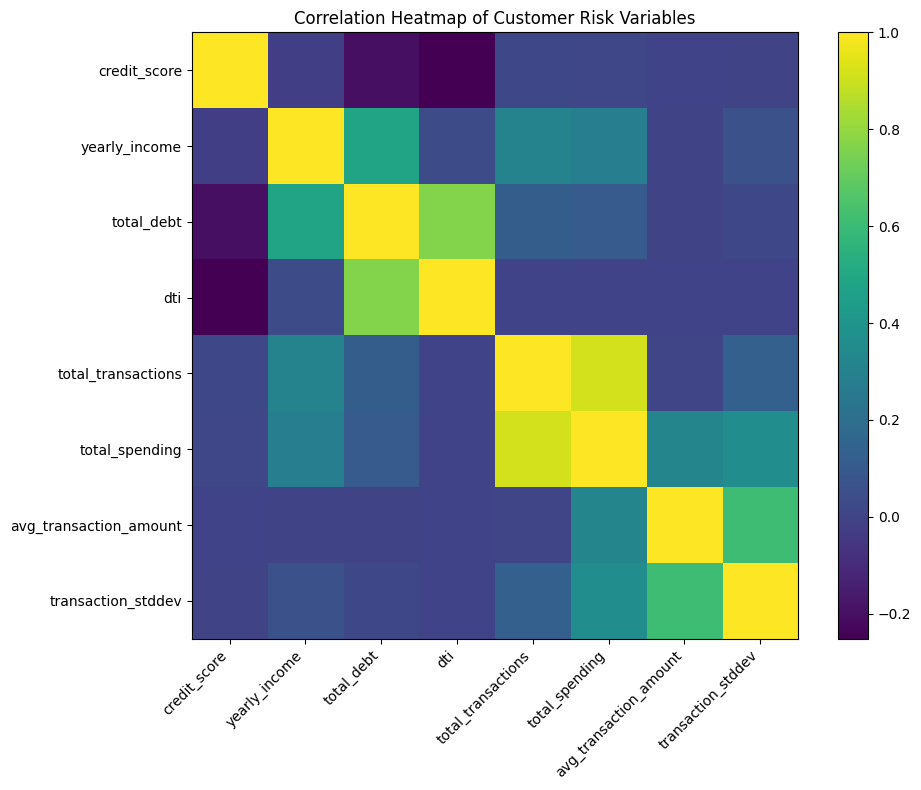

In [ ]:
import matplotlib.pyplot as plt

corr_matrix = customer_data[
    [
        'credit_score',
        'yearly_income',
        'total_debt',
        'dti',
        'total_transactions',
        'total_spending',
        'avg_transaction_amount',
        'transaction_stddev'
    ]
].corr()

plt.figure(figsize=(10, 8))

plt.imshow(corr_matrix)

plt.colorbar()

plt.xticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns,
    rotation=45,
    ha='right'
)

plt.yticks(
    range(len(corr_matrix.columns)),
    corr_matrix.columns
)

plt.title('Correlation Heatmap of Customer Risk Variables')

plt.tight_layout()

plt.show()

##19 — Monthly transaction activity
Does transaction activity change over time?

This is useful for the fraud/risk side because unusual changes in transaction volume can sometimes warrant investigation.

Step 1 — Aggregate transactions by month

In [ ]:
monthly_transactions = (
    df.groupby(df['date'].dt.to_period('M'))
      .size()
)

monthly_transactions

,0
date,
2023-01,625
2023-02,504
2023-03,623
2023-04,604
2023-05,595
2023-06,597
2023-07,569
2023-08,635
2023-09,540


Step 2 — Plot the trend

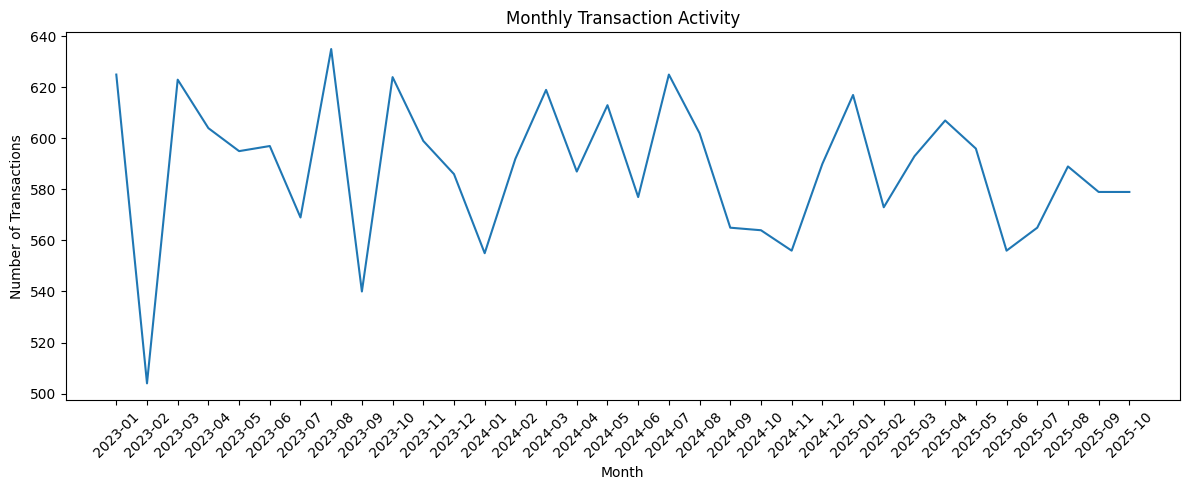

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_transactions.index.astype(str),
    monthly_transactions.values
)

plt.title('Monthly Transaction Activity')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##20 — Monthly transaction amount
Does monthly transaction value show any unusual patterns?

In [ ]:
monthly_amount = (
    df.groupby(df['date'].dt.to_period('M'))['amount']
      .sum()
)

monthly_amount

,amount
date,
2023-01,1969101.05
2023-02,1618166.26
2023-03,1967415.36
2023-04,1808112.16
2023-05,1848894.70
2023-06,1866320.05
2023-07,1777014.31
2023-08,1936159.34
2023-09,1661323.59


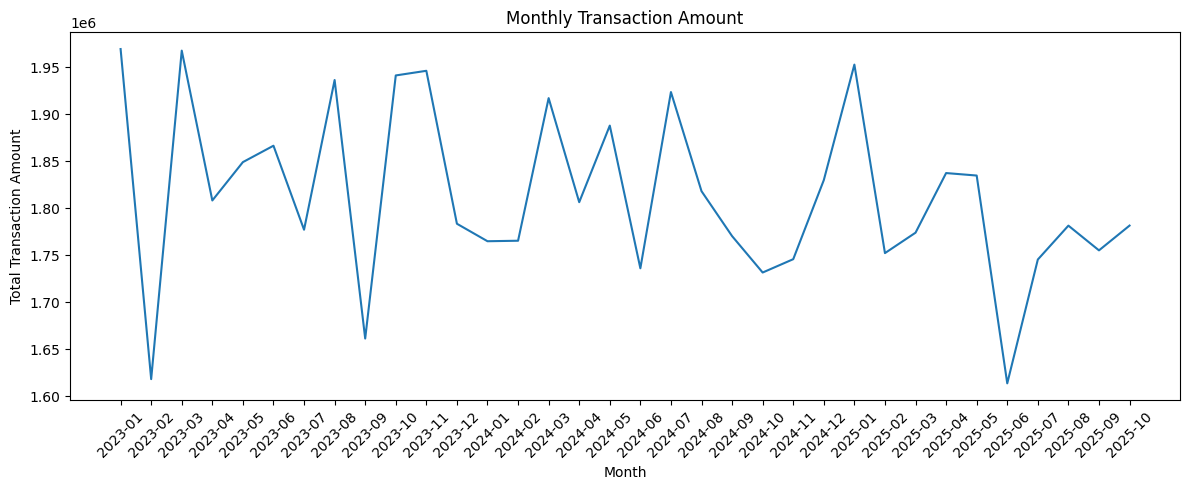

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_amount.index.astype(str),
    monthly_amount.values
)

plt.title('Monthly Transaction Amount')
plt.xlabel('Month')
plt.ylabel('Total Transaction Amount')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##21 — Unusually large individual transactions
"Which individual transactions are unusually large compared with the entire transaction population?"

Step 1 — Calculate the transaction-value threshold

In [ ]:
Q1_amount = df['amount'].quantile(0.25)
Q3_amount = df['amount'].quantile(0.75)

IQR_amount = Q3_amount - Q1_amount

upper_amount_bound = Q3_amount + 1.5 * IQR_amount

Q1_amount, Q3_amount, IQR_amount, upper_amount_bound

(np.float64(1531.1825),
 np.float64(4116.155),
 np.float64(2584.9725),
 np.float64(7993.6137499999995))

Step 2 — Identify the transactions

In [ ]:
large_transactions = df[
    df['amount'] > upper_amount_bound
].sort_values('amount', ascending=False)

large_transactions[
    ['transaction_id', 'client_id', 'amount', 'date', 'use_chip', 'merchant_id']
].head(10)

,transaction_id,client_id,amount,date,use_chip,merchant_id
8177,2067,CLTIND01465,19806.63,2024-11-23,Yes,MCH00123
12895,5474,CLTIND00523,18754.21,2024-05-14,No,MCH00255
5375,10859,CLTIND05808,18489.54,2024-05-09,Yes,MCH00098
4261,8630,CLTIND05786,17067.52,2025-09-09,Yes,MCH00392
11786,6988,CLTIND00304,16784.15,2025-07-11,No,MCH00309
18254,10898,CLTIND04894,16627.23,2025-01-20,Yes,MCH00216
14718,6273,CLTIND05124,16370.15,2024-02-11,Yes,MCH00024
16400,2266,CLTIND03665,16276.10,2025-01-09,Yes,MCH00196
18122,11532,CLTIND05035,15509.12,2023-01-17,Yes,MCH00445
16687,9761,CLTIND01156,14996.78,2023-04-09,No,MCH00048


Step 3 — Transaction Patterns & Financial Relationships

## Correlation Between Key Financial Variables

In [ ]:
len(large_transactions)

638

##22 — Large Transaction Behaviour Across Risk Segments
Do customers classified as High/Elevated Risk account for a disproportionate share of unusually large transactions?

In [ ]:
large_transactions = large_transactions.merge(
    customer_data[['client_id', 'risk_segment']],
    on='client_id',
    how='left'
)

In [ ]:
large_transactions['risk_segment'].value_counts()

,count
risk_segment,
Standard Risk,447
Elevated Risk,173
High Risk,18


In [ ]:
large_transaction_risk = (
    large_transactions['risk_segment']
    .value_counts(normalize=True)
    .mul(100)
)

large_transaction_risk

,proportion
risk_segment,
Standard Risk,70.062696
Elevated Risk,27.115987
High Risk,2.821317


##23 — Customer-Level Large Transaction Rate
"What proportion of each customer's transactions are unusually large?"

Step 1 — Count large transactions per customer

In [ ]:
large_counts = (
    large_transactions
    .groupby('client_id')
    .size()
    .reset_index(name='large_transaction_count')
)

Step 2 — Add total transaction count

In [ ]:
customer_behavior = customer_data[
    ['client_id', 'risk_segment', 'total_transactions']
].merge(
    large_counts,
    on='client_id',
    how='left'
)

In [ ]:
customer_behavior['large_transaction_count'] = (
    customer_behavior['large_transaction_count']
    .fillna(0)
)

Step 3 — Calculate the rate





In [ ]:
customer_behavior['large_transaction_rate'] = (
    customer_behavior['large_transaction_count']
    / customer_behavior['total_transactions']
)

Step 4 — Compare the rate across risk segments

In [ ]:
customer_behavior.groupby('risk_segment')['large_transaction_rate'].mean()

,large_transaction_rate
risk_segment,
Elevated Risk,0.032034
High Risk,0.035223
Standard Risk,0.030560


##24 — Segment-Level Large Transaction Rate
So let's calculate the overall large-transaction rate within each risk segment instead:

Number of large transactions ÷ total transactions in that segment.

In [ ]:
large_transaction_summary = (
    df.merge(
        customer_data[['client_id', 'risk_segment']],
        on='client_id',
        how='left'
    )
)

large_transaction_summary['is_large_transaction'] = (
    large_transaction_summary['amount'] > upper_amount_bound
).astype(int)

large_transaction_summary.groupby('risk_segment').agg(
    total_transactions=('transaction_id', 'count'),
    large_transactions=('is_large_transaction', 'sum')
)

,total_transactions,large_transactions
risk_segment,,
Elevated Risk,5108,173
High Risk,605,18
Standard Risk,14287,447


In [ ]:
segment_large_rate = (
    large_transaction_summary
    .groupby('risk_segment')
    .agg(
        total_transactions=('transaction_id', 'count'),
        large_transactions=('is_large_transaction', 'sum')
    )
)

segment_large_rate['large_transaction_rate'] = (
    segment_large_rate['large_transactions']
    / segment_large_rate['total_transactions']
)

segment_large_rate

,total_transactions,large_transactions,large_transaction_rate
risk_segment,,,
Elevated Risk,5108,173,0.033868
High Risk,605,18,0.029752
Standard Risk,14287,447,0.031287


##25 — Customer Risk Segmentation

## Financial Profile Comparison Across Risk Segments
We'll create a summary table by risk segment containing:

Number of customers
Average credit score
Average DTI
Average income
Average debt
Average spending
Average transactions

In [ ]:
risk_summary = (
    customer_data
    .groupby('risk_segment')
    .agg(
        customers=('client_id', 'count'),
        avg_credit_score=('credit_score', 'mean'),
        avg_dti=('dti', 'mean'),
        avg_income=('yearly_income', 'mean'),
        avg_debt=('total_debt', 'mean'),
        avg_spending=('total_spending', 'mean'),
        avg_transactions=('total_transactions', 'mean')
    )
    .reindex([
        'High Risk',
        'Elevated Risk',
        'Standard Risk'
    ])
)

risk_summary

,customers,avg_credit_score,avg_dti,avg_income,avg_debt,avg_spending,avg_transactions
risk_segment,,,,,,,
High Risk,146,593.465753,0.590216,719870.787671,425782.910959,12747.707534,4.143836
Elevated Risk,1298,619.038521,0.249876,654038.858243,163589.712635,12083.549900,3.935285
Standard Risk,3497,737.218187,0.140333,634554.304261,91018.600229,12610.844996,4.085502


What stands out?

1. High Risk customers have dramatically higher financial leverage.
Their average DTI is 59.02%, versus 14.03% for Standard Risk.

2. High Risk also has substantially higher average debt.
₹4.26L versus ₹0.91L for Standard Risk.

3. Credit quality is clearly separated.
Average credit score is ~593 for High Risk versus ~737 for Standard Risk.

4. Income doesn't differentiate the segments nearly as much.
Interestingly, High Risk customers actually have the highest average income at ₹7.20L. This is a useful reminder that higher income doesn't necessarily mean lower financial risk when debt levels are also high.

5. Transaction behaviour remains remarkably similar.
Average spending is around ₹12K across all three groups, and average transaction counts are around 4. This reinforces our earlier finding that basic transaction volume/spending isn't strongly differentiating the risk segments.

Key finding:

High-Risk customers exhibit substantially higher DTI and debt levels and lower credit scores, while income and basic transaction behaviour show considerably less differentiation across segments.

Important caveat:

Credit score and DTI differences are expected because they are components of the risk-segmentation framework itself. The more independent finding is that spending and transaction frequency remain broadly similar across segments.

##26 — Identifying the highest-risk customers
We want to identify customers who simultaneously have:

Low credit score
High DTI
High debt

In [ ]:
priority_customers = customer_data[
    (customer_data['credit_score'] < 650) &
    (customer_data['dti'] >= 0.50)
].copy()

priority_customers = priority_customers.sort_values(
    ['dti', 'total_debt'],
    ascending=False
)

priority_customers[
    [
        'client_id',
        'credit_score',
        'dti',
        'yearly_income',
        'total_debt',
        'total_spending',
        'total_transactions'
    ]
].head(10)

,client_id,credit_score,dti,yearly_income,total_debt,total_spending,total_transactions
3933,CLTIND04784,500,0.829226,2191664,1817384,8720.95,3
2266,CLTIND02766,622,0.784541,1002108,786195,28062.39,9
168,CLTIND00200,592,0.762742,253353,193243,5345.82,1
2339,CLTIND02855,624,0.745891,768280,573053,6850.80,2
880,CLTIND01067,640,0.742719,330569,245520,12367.48,6
2124,CLTIND02596,623,0.729500,824718,601632,15156.99,7
1272,CLTIND01556,578,0.729260,452756,330177,4034.33,2
1726,CLTIND02119,578,0.725044,961882,697407,15843.47,6
2477,CLTIND03028,527,0.724517,749098,542734,7603.19,2
4796,CLTIND05825,582,0.723248,491621,355564,5616.56,4


##27 — Building a Composite Risk Score
We'll create a simple 100-point Risk Score using three components:

| Credit score | Points |
| ------------ | -----: |
| < 600        |     40 |
| 600–649      |     30 |
| 650–699      |     20 |
| 700–749      |     10 |
| ≥ 750        |      0 |

| DTI       | Points |
| --------- | -----: |
| ≥ 70%     |     40 |
| 50–69.99% |     30 |
| 30–49.99% |     20 |
| 15–29.99% |     10 |
| < 15%     |      0 |

3. Debt level — 20 points

We'll use the dataset's debt distribution rather than arbitrarily picking a rupee threshold.

We'll first calculate the 75th and 90th percentiles:

In [ ]:
customer_data['total_debt'].quantile([0.75, 0.90])

,total_debt
0.75,172721.0
0.90,317328.0


 Create the Composite Risk Score

## Risk Score Methodology

A transparent composite risk score was developed using three customer-level financial indicators:

- **Credit Score (40 points):** Lower credit scores receive higher risk points.
- **Debt-to-Income Ratio (40 points):** Higher DTI values receive higher risk points.
- **Total Debt (20 points):** Higher debt exposure receives higher risk points.

The maximum possible composite risk score is **100**.

The weighting gives greater importance to credit quality and debt burden while incorporating absolute debt exposure as an additional risk dimension.

In [ ]:
customer_data['credit_risk_points'] = pd.cut(
    customer_data['credit_score'],
    bins=[-float('inf'), 599, 649, 699, 749, float('inf')],
    labels=[40, 30, 20, 10, 0]
).astype(int)

In [ ]:
customer_data['dti_risk_points'] = pd.cut(
    customer_data['dti'],
    bins=[-float('inf'), 0.149999, 0.299999, 0.499999, 0.699999, float('inf')],
    labels=[0, 10, 20, 30, 40]
).astype(int)

In [ ]:
customer_data['debt_risk_points'] = pd.cut(
    customer_data['total_debt'],
    bins=[-float('inf'), 172720.999, 317327.999, float('inf')],
    labels=[0, 10, 20]
).astype(int)

In [ ]:
customer_data['risk_score'] = (
    customer_data['credit_risk_points']
    + customer_data['dti_risk_points']
    + customer_data['debt_risk_points']
)

What we're building

Each customer can now score between:

0 → 100

where a higher score means more risk according to our analytical framework.

For example, a customer with:

Credit score = 580 → 40 points
DTI = 75% → 40 points
Debt = ₹400K → 20 points

would receive:

Risk Score = 100/100

Whereas someone with:

Credit score = 780 → 0
DTI = 10% → 0
Debt = ₹100K → 0

would receive:

Risk Score = 0/100

In [ ]:
customer_data[
    [
        'client_id',
        'credit_score',
        'dti',
        'total_debt',
        'credit_risk_points',
        'dti_risk_points',
        'debt_risk_points',
        'risk_score'
    ]
].sort_values('risk_score', ascending=False).head(10)

,client_id,credit_score,dti,total_debt,credit_risk_points,dti_risk_points,debt_risk_points,risk_score
4039,CLTIND04912,598,0.721866,449417,40,40,20,100
4796,CLTIND05825,582,0.723248,355564,40,40,20,100
1726,CLTIND02119,578,0.725044,697407,40,40,20,100
3933,CLTIND04784,500,0.829226,1817384,40,40,20,100
1569,CLTIND01923,587,0.718222,400897,40,40,20,100
1272,CLTIND01556,578,0.729260,330177,40,40,20,100
2477,CLTIND03028,527,0.724517,542734,40,40,20,100
2004,CLTIND02454,546,0.691876,659601,40,30,20,90
627,CLTIND00751,560,0.527582,1069522,40,30,20,90
4525,CLTIND05495,577,0.612438,356175,40,30,20,90


Methodology:

Credit score → 0–40 points
DTI → 0–40 points
Debt → 0–20 points
Maximum score → 100

Finding:

The composite score identifies customers exhibiting simultaneous weaknesses across credit quality, debt burden and absolute debt exposure. The highest-scoring customers reach 100/100 by meeting the most severe thresholds across all three dimensions.

Important caveat:

This is an analytical scoring framework created for the project, not a validated credit-risk model or underwriting score. The thresholds and weights are heuristic and would require historical outcome data and model validation before being used operationally.

##28 — Customers classification into each risk-score band
|      Score | Analytical category |
| ---------: | ------------------- |
| **80–100** | High                |
|  **60–79** | Moderate-High       |
|  **40–59** | Moderate            |
|   **0–39** | Low                 |


## Risk Score Bands and Customer Distribution

Customers were grouped into four project-defined risk-score bands to make the composite score easier to interpret:

- **Low:** 0–39
- **Moderate:** 40–59
- **Moderate-High:** 60–79
- **High:** 80–100

These categories are analytical classifications created for this project and do not represent official credit-risk policy thresholds.

In [ ]:
customer_data['score_band'] = pd.cut(
    customer_data['risk_score'],
    bins=[-1, 39, 59, 79, 100],
    labels=['Low', 'Moderate', 'Moderate-High', 'High']
)

In [ ]:
score_distribution = customer_data['score_band'].value_counts().sort_index()

score_distribution

,count
score_band,
Low,3271
Moderate,1027
Moderate-High,495
High,148


In [ ]:
score_distribution_pct = (
    customer_data['score_band']
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

score_distribution_pct

,proportion
score_band,
Low,66.201174
Moderate,20.785266
Moderate-High,10.018215
High,2.995345


##29 — Comparing the two risk frameworks
How much overlap exists between our original rule-based High Risk segment and our new composite-score High segment?

## Comparison with Rule-Based Risk Segmentation

The composite risk score was compared with the original customer risk segmentation framework to assess whether both approaches identify broadly similar patterns.

The comparison evaluates how customers classified as Standard Risk, Elevated Risk, and High Risk are distributed across the composite score bands.

In [ ]:
comparison = pd.crosstab(
    customer_data['risk_segment'],
    customer_data['score_band']
)

comparison

score_band,Low,Moderate,Moderate-High,High
risk_segment,,,,
Elevated Risk,317,541,393,47
High Risk,0,0,45,101
Standard Risk,2954,486,57,0


In [ ]:
high_overlap = customer_data[
    (customer_data['risk_segment'] == 'High Risk') &
    (customer_data['score_band'] == 'High')
].shape[0]

high_overlap

101

Finding:

101 of the 146 original High-Risk customers (69.2%) are classified as High under the composite score. No Standard-Risk customers receive a High composite score.

Key insight:

The two frameworks show substantial agreement at the extremes, while the composite score provides greater differentiation within the Elevated-Risk population.

Interpretation:

The composite score appears directionally consistent with the original framework while adding additional information from absolute debt exposure.

##30 — Visualizing the two risk frameworks

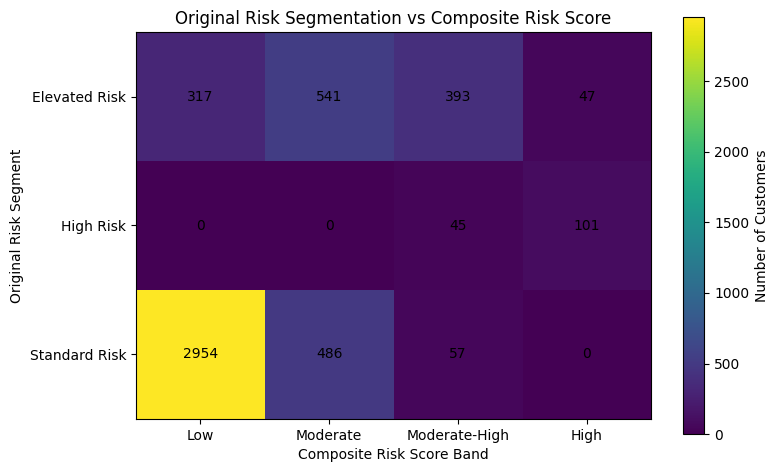

In [ ]:
import matplotlib.pyplot as plt

comparison = pd.crosstab(
    customer_data['risk_segment'],
    customer_data['score_band']
)

plt.figure(figsize=(8, 5))

plt.imshow(comparison)

plt.colorbar(label='Number of Customers')

plt.xticks(
    range(len(comparison.columns)),
    comparison.columns
)

plt.yticks(
    range(len(comparison.index)),
    comparison.index
)

plt.xlabel('Composite Risk Score Band')
plt.ylabel('Original Risk Segment')
plt.title('Original Risk Segmentation vs Composite Risk Score')

for i in range(comparison.shape[0]):
    for j in range(comparison.shape[1]):
        plt.text(
            j,
            i,
            comparison.iloc[i, j],
            ha='center',
            va='center'
        )

plt.tight_layout()
plt.show()

Finding:

The heatmap shows strong concentration of Standard-Risk customers in the Low score band and High-Risk customers predominantly in the High and Moderate-High bands.

Insight:

The composite score broadly preserves the original risk hierarchy while providing additional differentiation within the Elevated-Risk segment.

##31 — Ranking the highest-risk customers

In [ ]:
top_risk_customers = (
    customer_data[
        customer_data['score_band'] == 'High'
    ]
    .sort_values(
        ['risk_score', 'dti', 'total_debt'],
        ascending=[False, False, False]
    )
)

top_risk_customers[
    [
        'client_id',
        'risk_score',
        'credit_score',
        'dti',
        'yearly_income',
        'total_debt',
        'total_spending',
        'total_transactions'
    ]
].head(15)

,client_id,risk_score,credit_score,dti,yearly_income,total_debt,total_spending,total_transactions
3933,CLTIND04784,100,500,0.829226,2191664,1817384,8720.95,3
1272,CLTIND01556,100,578,0.729260,452756,330177,4034.33,2
1726,CLTIND02119,100,578,0.725044,961882,697407,15843.47,6
2477,CLTIND03028,100,527,0.724517,749098,542734,7603.19,2
4796,CLTIND05825,100,582,0.723248,491621,355564,5616.56,4
4039,CLTIND04912,100,598,0.721866,622577,449417,28021.87,7
1569,CLTIND01923,100,587,0.718222,558180,400897,2682.72,2
2266,CLTIND02766,90,622,0.784541,1002108,786195,28062.39,9
168,CLTIND00200,90,592,0.762742,253353,193243,5345.82,1
2339,CLTIND02855,90,624,0.745891,768280,573053,6850.80,2


Finding:

The composite score identifies a concentrated group of customers with simultaneously weak credit quality, high DTI and elevated absolute debt exposure. The highest-priority customers have risk scores of 100/100 and DTI levels above 70%.

Business use:

The ranking can serve as an analytical review queue for prioritizing customers requiring further investigation.

##32 — Visualizing the composite risk-score distribution

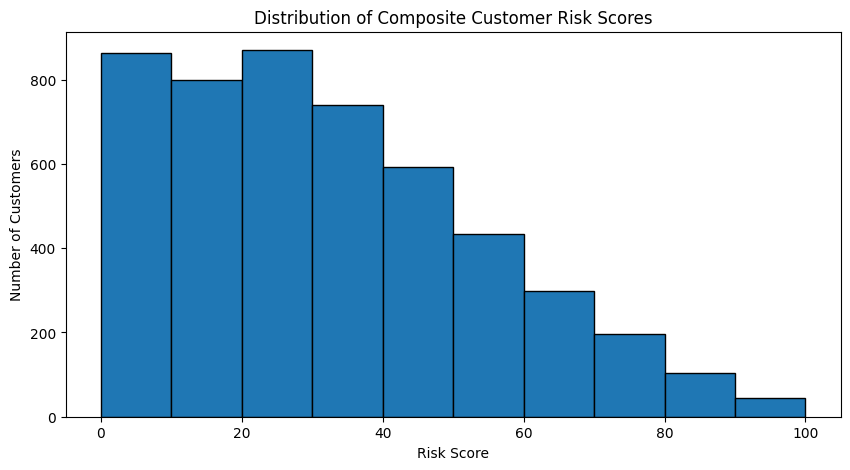

In [ ]:
plt.figure(figsize=(10, 5))

plt.hist(
    customer_data['risk_score'],
    bins=range(0, 101, 10),
    edgecolor='black'
)

plt.title('Distribution of Composite Customer Risk Scores')
plt.xlabel('Risk Score')
plt.ylabel('Number of Customers')

plt.show()

##33 — Let's check the exact score values

In [ ]:
customer_data['risk_score'].value_counts().sort_index()

,count
risk_score,
0,864
10,798
20,870
30,739
40,593
50,434
60,298
70,197
80,103


##34 — Continuous Risk Score for Customer Ranking
We'll use:

Credit score → lower score = higher risk
DTI → higher = higher risk
Total debt → higher = higher risk

In [ ]:
customer_data['credit_risk_normalized'] = (
    customer_data['credit_score'].max()
    - customer_data['credit_score']
) / (
    customer_data['credit_score'].max()
    - customer_data['credit_score'].min()
)

customer_data['dti_risk_normalized'] = (
    customer_data['dti']
    - customer_data['dti'].min()
) / (
    customer_data['dti'].max()
    - customer_data['dti'].min()
)

customer_data['debt_risk_normalized'] = (
    customer_data['total_debt']
    - customer_data['total_debt'].min()
) / (
    customer_data['total_debt'].max()
    - customer_data['total_debt'].min()
)

In [ ]:
customer_data['continuous_risk_score'] = (
    customer_data['credit_risk_normalized'] * 40
    + customer_data['dti_risk_normalized'] * 40
    + customer_data['debt_risk_normalized'] * 20
)

In [ ]:
customer_data[
    [
        'client_id',
        'credit_score',
        'dti',
        'total_debt',
        'risk_score',
        'continuous_risk_score'
    ]
].sort_values(
    'continuous_risk_score',
    ascending=False
).head(10)

,client_id,credit_score,dti,total_debt,risk_score,continuous_risk_score
3933,CLTIND04784,500,0.829226,1817384,100,93.402923
3295,CLTIND04025,484,0.667532,616872,90,73.727852
2477,CLTIND03028,527,0.724517,542734,100,72.069993
1717,CLTIND02108,496,0.669383,384570,90,70.258633
2004,CLTIND02454,546,0.691876,659601,90,70.194923
1828,CLTIND02239,492,0.614454,569824,90,69.981704
2266,CLTIND02766,622,0.784541,786195,90,69.711494
2898,CLTIND03541,451,0.507380,688103,90,69.542131
1726,CLTIND02119,578,0.725044,697407,100,69.538718
1950,CLTIND02384,627,0.575187,1725561,80,69.532739


##35 — Comparing the two scores

In [ ]:
customer_data[
    ['risk_score', 'continuous_risk_score']
].corr()

,risk_score,continuous_risk_score
risk_score,1.000000,0.949916
continuous_risk_score,0.949916,1.000000


In [ ]:
customer_data['risk_score'].corr(
    customer_data['continuous_risk_score']
)

np.float64(0.9499155871307984)

##36 — Final validation: Comparing risk scores across risk segments

Let's check whether our continuous risk score follows the same expected hierarchy across the original risk segments.

In [ ]:
customer_data.groupby('risk_segment').agg(
    customers=('client_id', 'count'),
    avg_risk_score=('risk_score', 'mean'),
    avg_continuous_risk_score=('continuous_risk_score', 'mean'),
    median_continuous_risk_score=('continuous_risk_score', 'median')
).round(2)

,customers,avg_risk_score,avg_continuous_risk_score,median_continuous_risk_score
risk_segment,,,,
Elevated Risk,1298,48.18,37.32,37.80
High Risk,146,79.93,58.75,57.53
Standard Risk,3497,17.96,21.36,19.69


#  Key Findings

The analysis identified several important patterns in customer financial profiles and transaction behaviour:

1. **Credit score and DTI show a negative relationship.** Customers with higher debt-to-income ratios generally tend to have lower credit scores.

2. **Total debt and DTI are positively related**, indicating that customers with greater debt burdens generally have higher debt-to-income ratios.

3. **Risk segments show clear differences in financial profiles.** High-Risk customers have the lowest average credit scores and the highest average DTI and debt levels.

4. **Spending and transaction frequency are relatively similar across risk segments.** This suggests that transaction activity alone may not be a strong differentiator of the financial-risk profiles defined in this analysis.

5. **Large transaction rates are broadly similar across the risk segments**, indicating that unusually large transactions do not appear to be strongly concentrated within one segment.

6. **A relatively small group of customers displays significantly elevated DTI levels**, making them potential candidates for further financial review.

7. **The bucket-based composite risk score is easy to interpret but provides limited granularity**, with customers concentrated at only a limited number of discrete score values.

8. **The continuous risk score provides more precise customer ranking** while maintaining strong alignment with the bucket-based framework.

9. **The correlation between the bucket-based and continuous risk scores is approximately 0.95**, indicating strong internal consistency between the two scoring approaches.

10. **Both risk-scoring approaches preserve the expected risk hierarchy**, with High-Risk customers receiving higher average risk scores than Elevated-Risk and Standard-Risk customers.

# Business Recommendations

Based on the analysis, the following actions could be considered:

### 1. Prioritize Customers with High DTI and Low Credit Scores

Customers displaying both high debt-to-income ratios and relatively low credit scores could be prioritized for further review, as these variables form the strongest basis of the project-defined risk framework.

### 2. Use Risk Scores for Prioritization Rather Than Automated Decisions

The composite risk score can be used to rank and prioritize customers for review. However, it should not be used independently for automated lending or credit decisions without validation using actual performance outcomes.

### 3. Apply the Continuous Score for Customer Ranking

The continuous risk score provides greater differentiation between customers with similar bucket-based scores and may be more useful when prioritizing customers within the same risk category.

### 4. Monitor High-DTI Customers

Customers with unusually high DTI values may require closer monitoring, particularly when combined with low credit scores or high absolute debt levels.

### 5. Incorporate Additional Behavioural and Performance Data

The framework could be improved by incorporating variables such as repayment history, delinquency, defaults, credit utilization, account tenure, and historical changes in financial behaviour.

### 6. Validate the Framework Using Actual Outcomes

Before deployment in a real-world environment, the scoring framework should be tested against historical outcomes such as delinquency, default, or credit loss to evaluate its predictive performance.

#Limitations & Conclusion

## Limitations

This analysis has several limitations:

- The dataset does not contain actual default, delinquency, repayment, or credit-loss outcomes.
- The risk segments and composite risk scores are exploratory analytical frameworks created specifically for this project.
- The selected score weights and thresholds are rule-based assumptions and have not been statistically optimized.
- The continuous risk score uses min-max normalization, which can be influenced by extreme values.
- The analysis identifies financial patterns and relative risk profiles but does not establish causation or predict actual customer default.

## Conclusion

This project demonstrates an end-to-end analytical workflow using SQL and Python to transform transaction-level data into customer-level financial profiles.

The analysis combines exploratory data analysis, customer segmentation, outlier detection, transaction analysis, and composite risk scoring to identify patterns associated with relatively elevated financial risk.

The results show that debt burden and credit quality provide meaningful differentiation across the project-defined risk segments. While the bucket-based scoring framework offers transparency and interpretability, the continuous scoring approach provides greater granularity for ranking customers.

Overall, the project demonstrates how SQL and Python can be used together to support structured customer profiling, risk prioritization, and exploratory financial analysis.